In [1]:
%matplotlib inline


# Faces recognition example using eigenfaces and SVMs

The dataset used in this example is a preprocessed excerpt of the
"Labeled Faces in the Wild", aka LFW_:

  http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz (233MB)


In [1]:
from time import time
import logging
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.svm import SVC


# #############################################################################
# Download the data, if not already on disk and load it as numpy arrays

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

### Step 1. Download the dataset
- Download the data
- Find the number of samples, number of features, number of classes

In [ ]:
n_samples, h, w = lfw_people.images.shape  # images are (n_samples, height, width)
X = lfw_people.data                        # feature matrix: shape (n_samples, n_features)
n_features = X.shape[1]
y = lfw_people.target                      # class labels
target_names = lfw_people.target_names
n_classes = len(target_names)

print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(f"Number of classes: {n_classes}")


Number of samples: 1288
Number of features: 1850
Number of classes: 7


### Step 2. Train the Model
- Split the data into test and train datasets
- Compute a PCA (eigenfaces) on the face dataset
- Train an SVM Model
- Create a confusion matrix to evaluate the model.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (966, 1850)
X_test shape: (322, 1850)


In [ ]:
# Compute PCA (eigenfaces) on the face dataset (treated as 2D images)   
pca = PCA(n_components=150, whiten=True, random_state=42).fit(X_train)
eigenfaces = pca.components_.reshape((150, h, w))
print(f"eigenfaces shape: {eigenfaces.shape}")
print(f"eigenfaces[0] shape: {eigenfaces[0].shape}")
print(f"eigenfaces[0] min: {eigenfaces[0].min()}")
print(f"eigenfaces[0] max: {eigenfaces[0].max()}")



eigenfaces shape: (150, 50, 37)
eigenfaces[0] shape: (50, 37)
eigenfaces[0] min: 0.0028264333959668875
eigenfaces[0] max: 0.030368832871317863


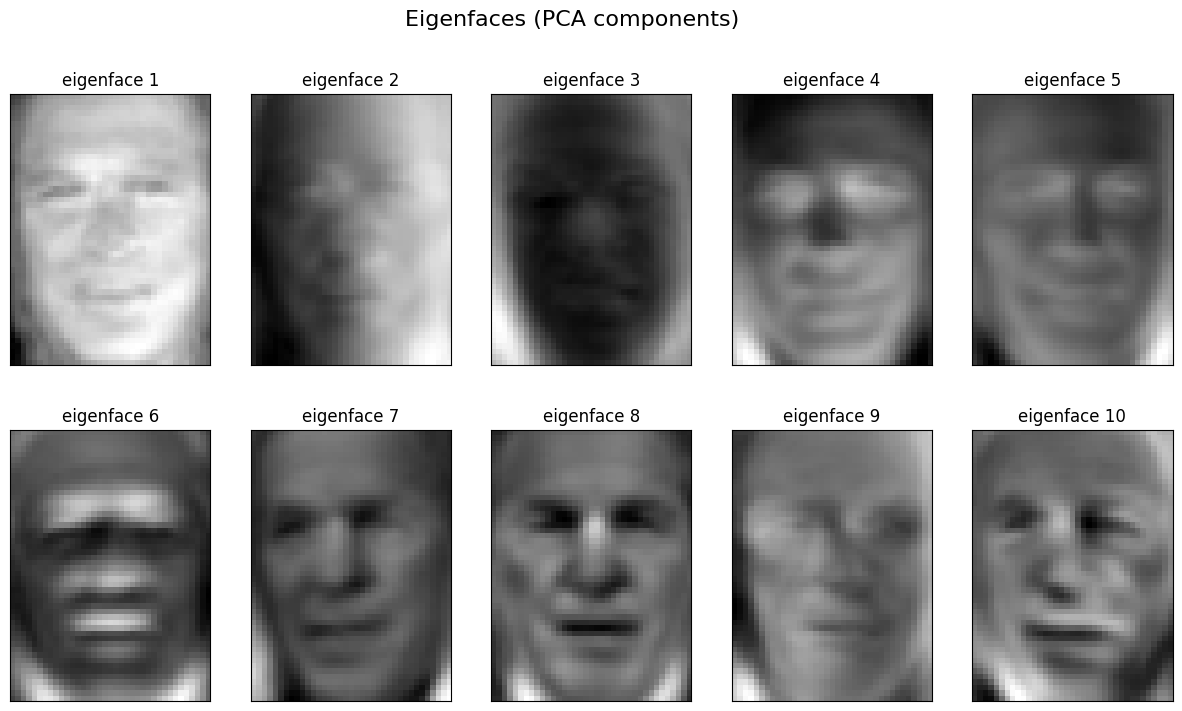

In [7]:
# Plot the first 10 eigenfaces
plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(eigenfaces[i], cmap=plt.cm.gray)
    plt.title(f"eigenface {i + 1}")
    plt.xticks(())
    plt.yticks(())
plt.suptitle("Eigenfaces (PCA components)", fontsize=16)
plt.show()

In [8]:
# Train a SVC on the PCA features   
# Note: The PCA step is not included in the pipeline, so we need to transform the data manually
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")


X_train_pca shape: (966, 150)
X_test_pca shape: (322, 150)


In [9]:
# Create a SVC classifier with a linear kernel
svc = SVC(kernel="linear", class_weight="balanced", random_state=42)
# Fit the classifier to the training data
t0 = time()
svc.fit(X_train_pca, y_train)
t1 = time()
print(f"Training time: {t1 - t0:.3f} seconds")

Training time: 0.110 seconds


In [10]:
# Predict the labels of the test set
t0 = time() 
y_pred = svc.predict(X_test_pca)
t1 = time()
print(f"Prediction time: {t1 - t0:.3f} seconds")

Prediction time: 0.020 seconds


                   precision    recall  f1-score   support

     Ariel Sharon      0.652     0.789     0.714        19
     Colin Powell      0.708     0.780     0.742        59
  Donald Rumsfeld      0.600     0.600     0.600        30
    George W Bush      0.833     0.827     0.830       133
Gerhard Schroeder      0.750     0.667     0.706        27
      Hugo Chavez      0.733     0.611     0.667        18
       Tony Blair      0.788     0.722     0.754        36

         accuracy                          0.758       322
        macro avg      0.723     0.714     0.716       322
     weighted avg      0.760     0.758     0.758       322



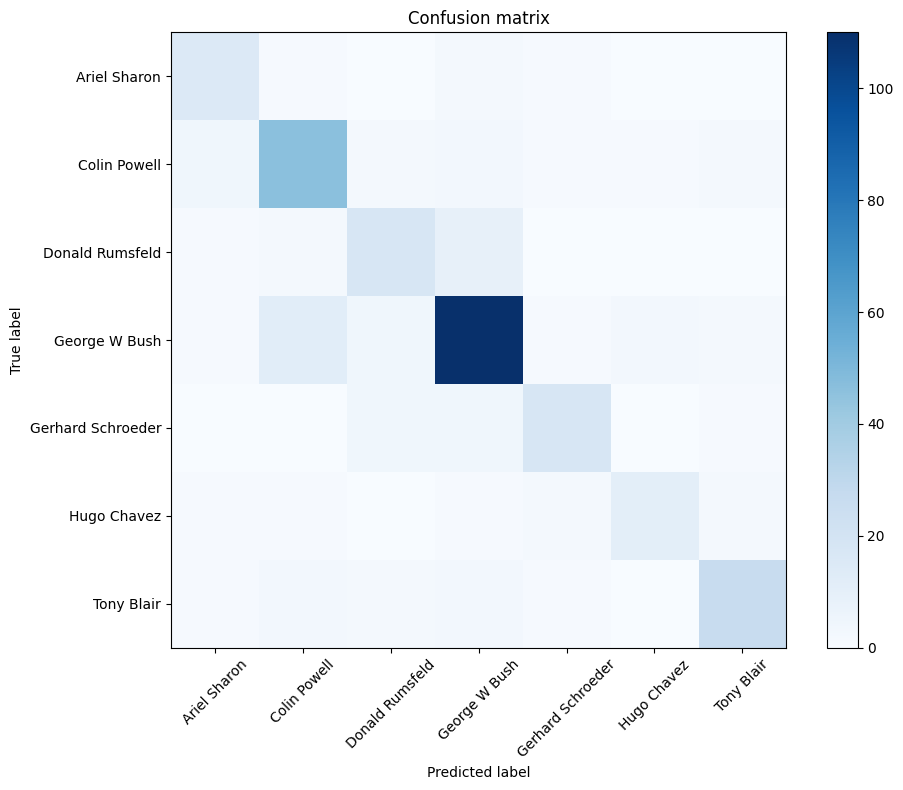

In [11]:
# Print the classification report
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = range(n_classes)
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()